In [46]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier  
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

In [47]:
# Load data (Dataset "Older Dataset for Don't overfit II challenge"
# Which dataset provided by User:"Md Mubasir" 
train = pd.read_csv('/kaggle/input/older-dataset-for-dont-overfit-ii-challenge/train.csv')
test = pd.read_csv('/kaggle/input/older-dataset-for-dont-overfit-ii-challenge/test.csv')

x_train_data = train.drop(['id', 'target'], axis=1)
y_train_data = train['target']

x_test = test.drop('id', axis=1)
test_ids = test['id'].values

x_train, x_val, y_train, y_val = train_test_split(
    x_train_data, 
    y_train_data, 
    test_size=0.2, 
    random_state=22027226, 
    stratify=y_train_data
)

Logistic Regression AUC (Validation): 0.7431
Logistic Regression Accuracy: 0.7200

Logistic Regression:
   Metric    Value
 Accuracy 0.720000
Precision 0.750000
   Recall 0.843750
 F1-score 0.794118
  AUC-ROC 0.743056


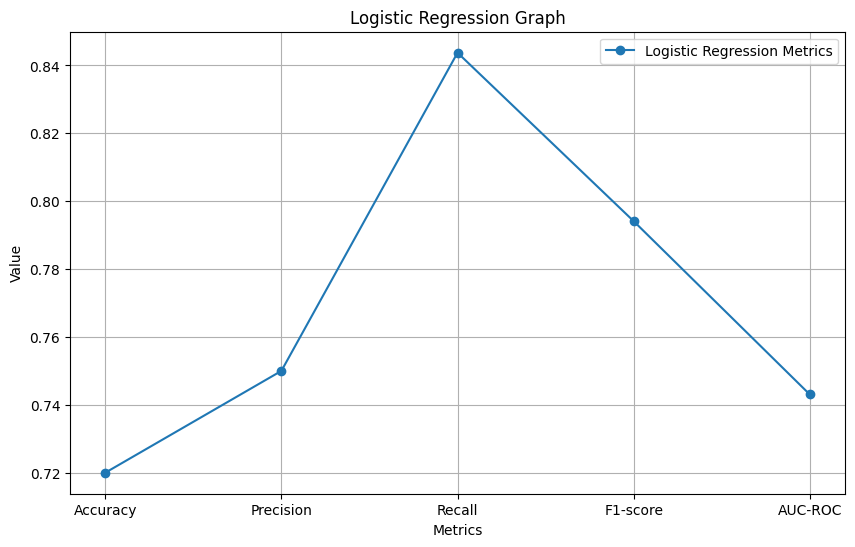

submission_v1.csv


In [48]:
lg = LogisticRegression(random_state=22027226, max_iter=1000)
lg.fit(x_train, y_train)

# Predict on validation set 
val_probs = lg.predict_proba(x_val)[:, 1]
val_predictions = lg.predict(x_val) 

# Evaluate metrics (focus on AUC for this competition)
lg_accuracy = accuracy_score(y_val, val_predictions)
lg_precision = precision_score(y_val, val_predictions)
lg_recall = recall_score(y_val, val_predictions)
lg_f1 = f1_score(y_val, val_predictions)
lg_auc = roc_auc_score(y_val, val_probs)

print(f'Logistic Regression AUC (Validation): {lg_auc:.4f}')
print(f'Logistic Regression Accuracy: {lg_accuracy:.4f}')

# Create DataFrame for metrics (added AUC)
lg_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"],
    "Value": [lg_accuracy, lg_precision, lg_recall, lg_f1, lg_auc]
})

print("\nLogistic Regression:")
print(lg_metrics_df.to_string(index=False))

# Plot metrics
plt.figure(figsize=(10, 6))
plt.plot(lg_metrics_df["Metric"], lg_metrics_df["Value"], marker='o', linestyle='-', label="Logistic Regression Metrics")
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.title("Logistic Regression Graph")
plt.legend()
plt.grid()
plt.show()


# Predict probabilities on test (for AUC evaluation)
lg.fit(x_train_data, y_train_data)
test_predictions = lg.predict_proba(x_test)[:, 1]

# Prepare submission CSV (id + target probabilities)
submission = pd.DataFrame({'id': test_ids, 'target': test_predictions})
submission.to_csv('submission_v1.csv', index=False)
print("submission_v1.csv") 

In [49]:
# Prepare features and targets
x_train_data = train.drop(['id', 'target'], axis=1)
y_train_data = train['target']

x_test = test.drop('id', axis=1)
test_ids = test['id'].values

scaler = StandardScaler()
x_Strain_data = scaler.fit_transform(x_train_data)
x_Stest = scaler.transform(x_test)

datafilter = VarianceThreshold(threshold=0.7)
x_Strain_data_filter = datafilter.fit_transform(x_Strain_data)
x_Stest_filter = datafilter.transform(x_Stest)

# Split train into train/val for evaluation (80/20, stratified to handle imbalance)
x_train, x_val, y_train, y_val = train_test_split(
    x_Strain_data_filter, 
    y_train_data, 
    test_size=0.2, 
    random_state=22027226, 
    stratify=y_train_data
)

Logistic Regression AUC (Validation): 0.7517
Logistic Regression Accuracy: 0.7200

Logistic Regression:
   Metric    Value
 Accuracy 0.720000
Precision 0.750000
   Recall 0.843750
 F1-score 0.794118
  AUC-ROC 0.751736


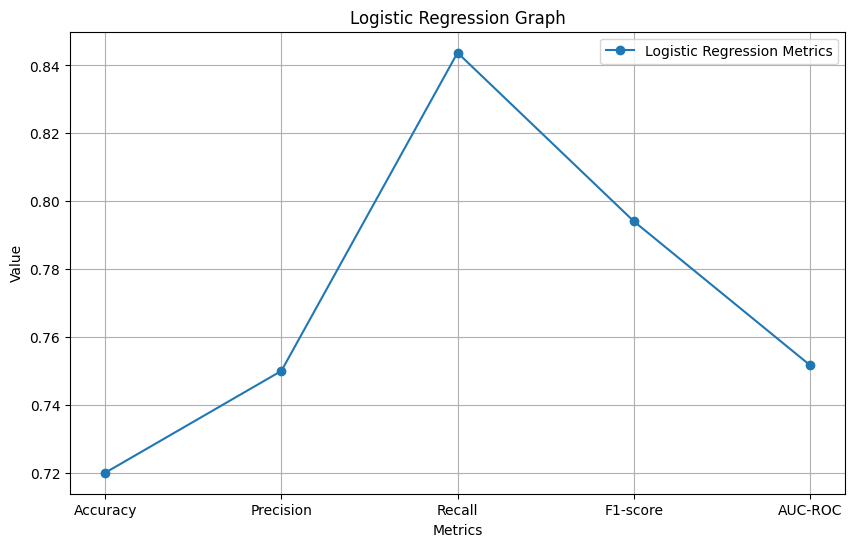

submission_v2.csv


In [50]:

# Logistic Regression 
lg = LogisticRegression(random_state=22027226, max_iter=1000)
lg.fit(x_train, y_train)

# Predict on validation set 
val_probs = lg.predict_proba(x_val)[:, 1]
val_predictions = lg.predict(x_val) 

# Evaluate metrics (focus on AUC for this competition)
lg_accuracy = accuracy_score(y_val, val_predictions)
lg_precision = precision_score(y_val, val_predictions)
lg_recall = recall_score(y_val, val_predictions)
lg_f1 = f1_score(y_val, val_predictions)
lg_auc = roc_auc_score(y_val, val_probs)

print(f'Logistic Regression AUC (Validation): {lg_auc:.4f}')
print(f'Logistic Regression Accuracy: {lg_accuracy:.4f}')

# Create DataFrame for metrics (added AUC)
lg_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"],
    "Value": [lg_accuracy, lg_precision, lg_recall, lg_f1, lg_auc]
})

print("\nLogistic Regression:")
print(lg_metrics_df.to_string(index=False))

# Plot metrics
plt.figure(figsize=(10, 6))
plt.plot(lg_metrics_df["Metric"], lg_metrics_df["Value"], marker='o', linestyle='-', label="Logistic Regression Metrics")
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.title("Logistic Regression Graph")
plt.legend()
plt.grid()
plt.show()

# Retrain on train set for submission
lg.fit(x_Strain_data_filter, y_train_data)

# Predict probabilities on test (for AUC evaluation)
test_predictions = lg.predict_proba(x_Stest_filter)[:, 1]

# Prepare submission CSV (id + target probabilities)
submission = pd.DataFrame({'id': test_ids, 'target': test_predictions})
submission.to_csv('submissionv_v2.csv', index=False)
print("submission_v2.csv") 

C=0.005, Validation AUC=0.7743
C=0.01, Validation AUC=0.7691
C=0.03, Validation AUC=0.7691
C=0.05, Validation AUC=0.7587
C=0.05, Validation AUC=0.7587
C=0.1, Validation AUC=0.7535
C=0.5, Validation AUC=0.7517
C=1.0, Validation AUC=0.7517
C=1.5, Validation AUC=0.7517
C=3.5, Validation AUC=0.7517
C=5.5, Validation AUC=0.7517
C=7.5, Validation AUC=0.7535
C=10.0, Validation AUC=0.7535
Best C=0.005, Best AUC=0.7743
Logistic Regression AUC (Validation): 0.7743
Logistic Regression Accuracy: 0.6600

Logistic Regression:
   Metric    Value
 Accuracy 0.660000
Precision 0.666667
   Recall 0.937500
 F1-score 0.779221
  AUC-ROC 0.774306


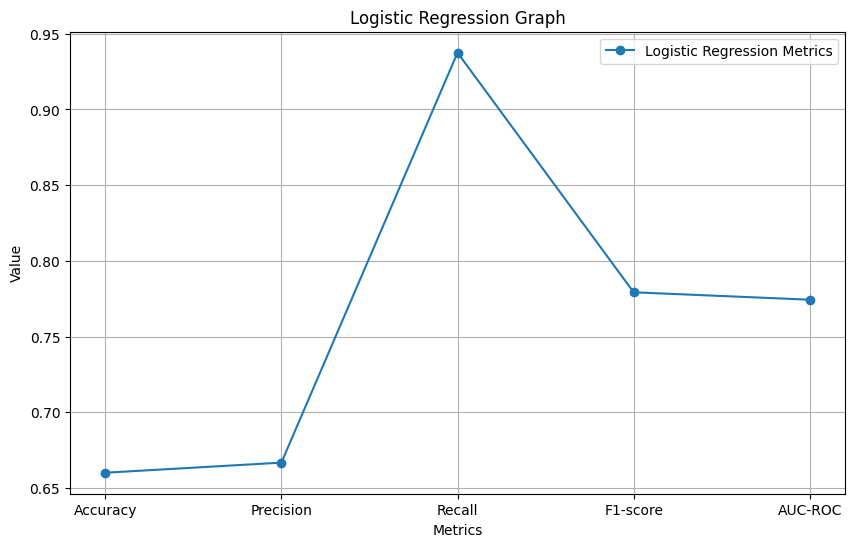

submission_v3.csv


In [51]:
# Find the best C
C_values = [0.005, 0.01, 0.03, 0.05,
            0.05, 0.1, 0.5, 1.0, 
            1.5, 3.5, 5.5, 7.5, 10.0]
best_C = 1.0
best_auc = 0

for C in C_values:
    lg = LogisticRegression(C=C, random_state=22027226, max_iter=1000)
    lg.fit(x_train, y_train)  
    val_probs = lg.predict_proba(x_val)[:, 1]
    auc = roc_auc_score(y_val, val_probs)
    print(f'C={C}, Validation AUC={auc:.4f}')
    if auc > best_auc:
        best_auc = auc
        best_C = C
print(f'Best C={best_C}, Best AUC={best_auc:.4f}')

# Logistic Regression 
lg = LogisticRegression(C=best_C,random_state=22027226, max_iter=1000)
lg.fit(x_train, y_train)

# Predict on validation set 
val_probs = lg.predict_proba(x_val)[:, 1]
val_predictions = lg.predict(x_val) 

# Evaluate metrics (focus on AUC for this competition)
lg_accuracy = accuracy_score(y_val, val_predictions)
lg_precision = precision_score(y_val, val_predictions)
lg_recall = recall_score(y_val, val_predictions)
lg_f1 = f1_score(y_val, val_predictions)
lg_auc = roc_auc_score(y_val, val_probs)

print(f'Logistic Regression AUC (Validation): {lg_auc:.4f}')
print(f'Logistic Regression Accuracy: {lg_accuracy:.4f}')

# Create DataFrame for metrics (added AUC)
lg_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"],
    "Value": [lg_accuracy, lg_precision, lg_recall, lg_f1, lg_auc]
})

print("\nLogistic Regression:")
print(lg_metrics_df.to_string(index=False))

# Plot metrics
plt.figure(figsize=(10, 6))
plt.plot(lg_metrics_df["Metric"], lg_metrics_df["Value"], marker='o', linestyle='-', label="Logistic Regression Metrics")
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.title("Logistic Regression Graph")
plt.legend()
plt.grid()
plt.show()

# Retrain on train set for submission
lg.fit(x_Strain_data_filter, y_train_data)

# Predict probabilities on test (for AUC evaluation)
test_predictions = lg.predict_proba(x_Stest_filter)[:, 1]

# Prepare submission CSV (id + target probabilities)
submission = pd.DataFrame({'id': test_ids, 'target': test_predictions})
submission.to_csv('submissionv_v3.csv', index=False)
print("submission_v3.csv") 

In [52]:
C_values = [0.005, 0.01, 0.03, 0.05,
            0.05, 0.1, 0.5, 1.0, 
            1.5, 3.5, 5.5, 7.5, 10.0]
precision_recall_sum = []
precision_recall_diff = []  
precision_recall_C_index = []  

best_auc = 0
best_C = None

for C in C_values:
    lg = LogisticRegression(C=C, random_state=22027226, max_iter=1000)
    lg.fit(x_train, y_train)
    
    # Predict on validation set 
    val_probs = lg.predict_proba(x_val)[:, 1]
    val_predictions = lg.predict(x_val) 
    
    # Evaluate metrics (focus on AUC for this competition)
    lg_accuracy = accuracy_score(y_val, val_predictions)
    lg_precision = precision_score(y_val, val_predictions, zero_division=0)
    lg_recall = recall_score(y_val, val_predictions, zero_division=0)
    lg_f1 = f1_score(y_val, val_predictions, zero_division=0)
    lg_auc = roc_auc_score(y_val, val_probs)

    s1 = (lg_precision/(lg_precision+lg_recall))*100
    s2 = (lg_recall/(lg_precision+lg_recall))*100
    s0 = s1-s2
    if(s0<0):
        s0 = s0 * (-1)

    # Ensure s0 is unique in precision_recall_diff
    if s0 not in precision_recall_diff:
        if len(precision_recall_diff) < 3:
            precision_recall_sum.append((lg_precision+lg_recall)*100)  # Store the sum of s1 and s2
            precision_recall_diff.append(s0)  # Add s0 if there's space
            precision_recall_C_index.append(C)  # Store corresponding C value
        else:
            # Replace the largest value in precision_recall_diff if s0 is smaller
            max_value = max(precision_recall_diff)
            if s0 < max_value:
                index_to_replace = precision_recall_diff.index(max_value)
                precision_recall_sum[index_to_replace] = (lg_precision+lg_recall)*100
                precision_recall_diff[index_to_replace] = s0
                precision_recall_C_index[index_to_replace] = C

    # Sort precision_recall_diff to ensure they're aligned
    sorted_indices = np.argsort(precision_recall_diff)
    precision_recall_sum = [precision_recall_sum[i] for i in sorted_indices]
    precision_recall_diff = [precision_recall_diff[i] for i in sorted_indices]
    precision_recall_C_index = [precision_recall_C_index[i] for i in sorted_indices]

    print(f'C={C}, Validation AUC={lg_auc:.4f}')


print(precision_recall_sum)
print(precision_recall_diff)
print(precision_recall_C_index)


C=0.005, Validation AUC=0.7743
C=0.01, Validation AUC=0.7691
C=0.03, Validation AUC=0.7691
C=0.05, Validation AUC=0.7587
C=0.05, Validation AUC=0.7587
C=0.1, Validation AUC=0.7535
C=0.5, Validation AUC=0.7517
C=1.0, Validation AUC=0.7517
C=1.5, Validation AUC=0.7517
C=3.5, Validation AUC=0.7517
C=5.5, Validation AUC=0.7517
C=7.5, Validation AUC=0.7535
C=10.0, Validation AUC=0.7535
[159.375, 161.1842105263158, 159.2948717948718]
[5.882352941176478, 8.571428571428577, 9.859154929577464]
[1.0, 0.1, 0.05]


Logistic Regression AUC (Validation): 0.7517
Logistic Regression Accuracy: 0.7200

Logistic Regression:
   Metric    Value
 Accuracy 0.720000
Precision 0.750000
   Recall 0.843750
 F1-score 0.794118
  AUC-ROC 0.751736


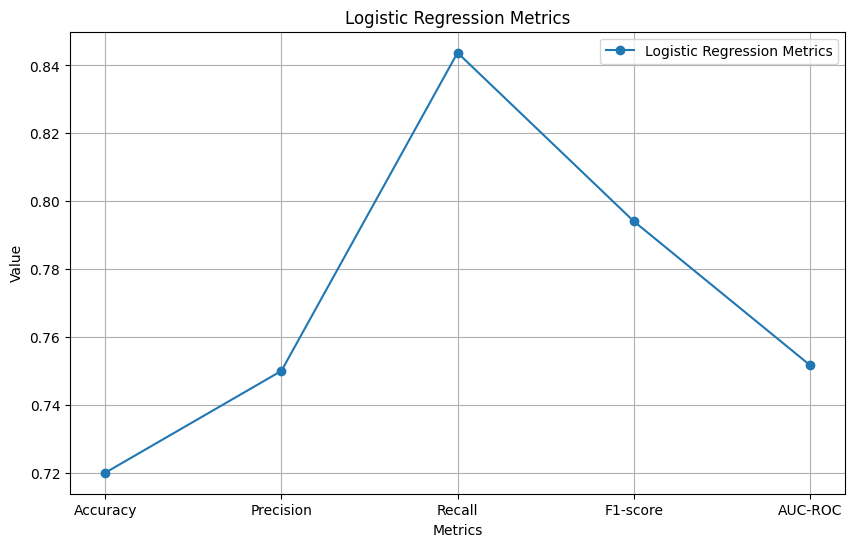

submission_v4_Cindex0.csv


In [53]:

# Retrain on the full training set with the best C
lg = LogisticRegression(
    C=precision_recall_C_index[0], 
    random_state=22027226, 
    max_iter=1000
)

lg.fit(x_train, y_train)

# Predict probabilities on validation set 
val_probs = lg.predict_proba(x_val)[:, 1]
val_predictions = lg.predict(x_val) 

# Evaluate metrics again
lg_accuracy = accuracy_score(y_val, val_predictions)
lg_precision = precision_score(y_val, val_predictions, zero_division=0)
lg_recall = recall_score(y_val, val_predictions, zero_division=0)
lg_f1 = f1_score(y_val, val_predictions, zero_division=0)
lg_auc = roc_auc_score(y_val, val_probs)


print(f'Logistic Regression AUC (Validation): {lg_auc:.4f}')
print(f'Logistic Regression Accuracy: {lg_accuracy:.4f}')

# Create DataFrame for metrics
lg_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"],
    "Value": [lg_accuracy, lg_precision, lg_recall, lg_f1, lg_auc]
})

print("\nLogistic Regression:")
print(lg_metrics_df.to_string(index=False))

# Plot metrics
plt.figure(figsize=(10, 6))
plt.plot(lg_metrics_df["Metric"], lg_metrics_df["Value"], marker='o', linestyle='-', label="Logistic Regression Metrics")
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.title("Logistic Regression Metrics")
plt.legend()
plt.grid()
plt.show()

# Retrain on train set for submission
lg.fit(x_Strain_data_filter, y_train_data)

# Predict probabilities on test (for AUC evaluation)
test_predictions = lg.predict_proba(x_Stest_filter)[:, 1]

# Prepare submission CSV (id + target probabilities)
submission = pd.DataFrame({'id': test_ids, 'target': test_predictions})
submission.to_csv('submission_v4_Cindex0.csv', index=False)
print("submission_v4_Cindex0.csv")


In [54]:
max_depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 10]  
precision_recall_sum = []
precision_recall_diff = []  
precision_recall_param_index = []  

best_auc = 0
best_D = 0
nes = 10 #10,50,100,200 

for d in max_depth_values:
    rf = RandomForestClassifier(max_depth=d, n_estimators=nes, random_state=22027226) 
    rf.fit(x_train, y_train)
    
    # Predict on validation set 
    val_probs = rf.predict_proba(x_val)[:, 1]
    val_predictions = rf.predict(x_val) 
    
    # Evaluate metrics (focus on AUC for this competition)
    rf_accuracy = accuracy_score(y_val, val_predictions)
    rf_precision = precision_score(y_val, val_predictions, zero_division=0)
    rf_recall = recall_score(y_val, val_predictions, zero_division=0)
    rf_f1 = f1_score(y_val, val_predictions, zero_division=0)
    rf_auc = roc_auc_score(y_val, val_probs)

    if rf_auc > best_auc:
        best_auc = rf_auc
        best_D = d
       
    print(f'max_depth={d}, Validation AUC={rf_auc:.4f}')

print(f'best_D={best_D}, best_auc={best_auc:.4f}')

max_depth=1, Validation AUC=0.5599
max_depth=2, Validation AUC=0.6675
max_depth=3, Validation AUC=0.6059
max_depth=4, Validation AUC=0.6198
max_depth=5, Validation AUC=0.5095
max_depth=6, Validation AUC=0.6562
max_depth=7, Validation AUC=0.6363
max_depth=8, Validation AUC=0.5911
max_depth=10, Validation AUC=0.4523
best_D=2, best_auc=0.6675


Random Forest AUC (Validation): 0.6675
Random Forest Accuracy: 0.6200

Random Forest Metrics Table:
   Metric    Value
 Accuracy 0.620000
Precision 0.632653
   Recall 0.968750
 F1-score 0.765432
  AUC-ROC 0.667535


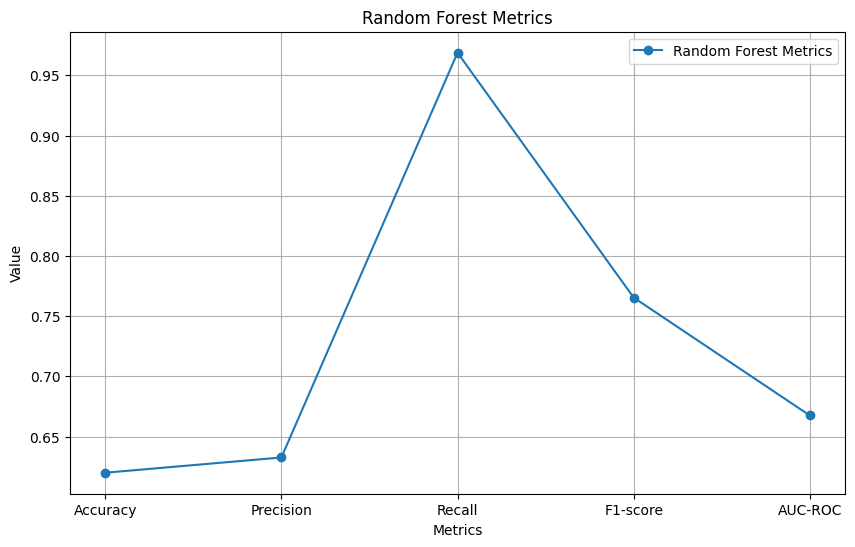

submission_v5_RandomForest.csv


In [55]:
# Retrain on the full training set with the best param
rf = RandomForestClassifier(
    max_depth=best_D, 
    n_estimators=nes,
    random_state=22027226
)

rf.fit(x_train, y_train)

# Predict probabilities on validation set 
val_probs = rf.predict_proba(x_val)[:, 1]
val_predictions = rf.predict(x_val) 

# Evaluate metrics again
rf_accuracy = accuracy_score(y_val, val_predictions)
rf_precision = precision_score(y_val, val_predictions, zero_division=0)
rf_recall = recall_score(y_val, val_predictions, zero_division=0)
rf_f1 = f1_score(y_val, val_predictions, zero_division=0)
rf_auc = roc_auc_score(y_val, val_probs)

print(f'Random Forest AUC (Validation): {rf_auc:.4f}')
print(f'Random Forest Accuracy: {rf_accuracy:.4f}')

# Create DataFrame for metrics
rf_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"],
    "Value": [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_auc]
})

print("\nRandom Forest Metrics Table:")
print(rf_metrics_df.to_string(index=False))

# Plot metrics
plt.figure(figsize=(10, 6))
plt.plot(rf_metrics_df["Metric"], rf_metrics_df["Value"], marker='o', linestyle='-', label="Random Forest Metrics")
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.title("Random Forest Metrics")
plt.legend()
plt.grid()
plt.show()

# Retrain on full train set for submission
rf.fit(x_Strain_data_filter, y_train_data)

# Predict probabilities on test (for AUC evaluation)
test_predictions = rf.predict_proba(x_Stest_filter)[:, 1]

# Prepare submission CSV (id + target probabilities)
submission = pd.DataFrame({'id': test_ids, 'target': test_predictions})
submission.to_csv('submission_v5_RandomForest.csv', index=False)
print("submission_v5_RandomForest.csv") 

XGBoost AUC (Validation): 0.7135
XGBoost Accuracy: 0.6800

XGBoost Metrics Table:
   Metric    Value
 Accuracy 0.680000
Precision 0.722222
   Recall 0.812500
 F1-score 0.764706
  AUC-ROC 0.713542


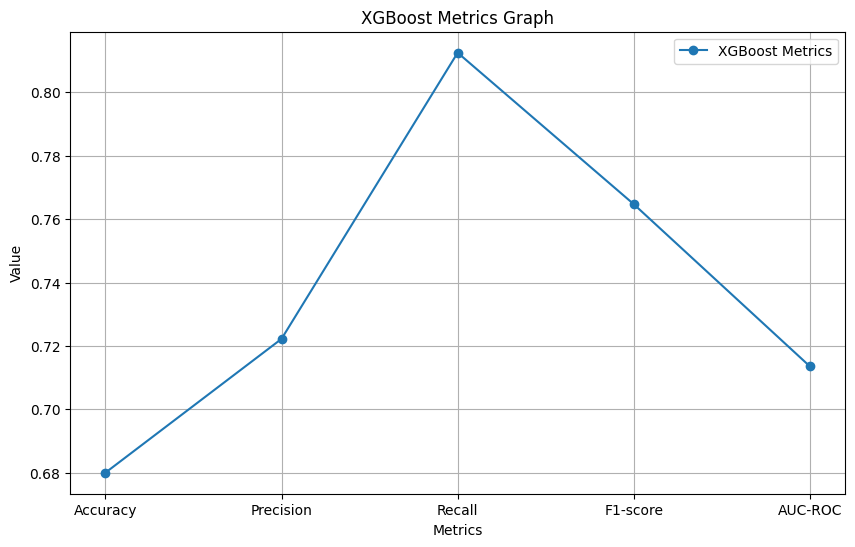

submission_v6_XGBoost.csv


In [56]:
xgb = XGBClassifier(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=best_D,  # Used the best depth parameter
    random_state=22027226,
    use_label_encoder=False,
    eval_metric='logloss'  # Set evaluation metric
)

# Fit the model
xgb.fit(x_train, y_train)

# Predict probabilities on validation set 
val_probs = xgb.predict_proba(x_val)[:, 1]
val_predictions = xgb.predict(x_val) 

# Evaluate metrics
xgb_accuracy = accuracy_score(y_val, val_predictions)
xgb_precision = precision_score(y_val, val_predictions, zero_division=0)
xgb_recall = recall_score(y_val, val_predictions, zero_division=0)
xgb_f1 = f1_score(y_val, val_predictions, zero_division=0)
xgb_auc = roc_auc_score(y_val, val_probs)

print(f'XGBoost AUC (Validation): {xgb_auc:.4f}')
print(f'XGBoost Accuracy: {xgb_accuracy:.4f}')

# Create DataFrame for metrics
xgb_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"],
    "Value": [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_auc]
})

print("\nXGBoost Metrics Table:")
print(xgb_metrics_df.to_string(index=False))

# Plot metrics
plt.figure(figsize=(10, 6))
plt.plot(xgb_metrics_df["Metric"], xgb_metrics_df["Value"], marker='o', linestyle='-', label="XGBoost Metrics")
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.title("XGBoost Metrics Graph")
plt.legend()
plt.grid()
plt.show()

# Retrain on full train set for submission
xgb.fit(x_train_data, y_train_data)

# Predict probabilities on test (for AUC evaluation)
test_predictions = xgb.predict_proba(x_test)[:, 1]

# Prepare submission CSV (id + target probabilities)
submission = pd.DataFrame({'id': test_ids, 'target': test_predictions})
submission.to_csv('submission_v6_XGBoost.csv', index=False)
print("submission_v6_XGBoost.csv") 